In [2]:
#Імпортуємо лише найнеобхідніші та дозволені бібліотеки
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

#Зчитуємо датасет
df = pd.read_csv('/content/train.csv')

#Виводимо розмірність датасету та перші 5 рядків для перевірки
print(f"Розмір датасету: {df.shape}")
display(df.head())

Розмір датасету: (1460, 81)


,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000


In [3]:
#Первинний аналіз виводимо базові статистичні характеристики
print("Базова статистика числових змінних:")
display(df.describe())

#2 Відбір ознак Feature Selection
#Обираємо лише числові колонки для обчислення кореляції
numeric_df = df.select_dtypes(include=[np.number])
correlations = numeric_df.corr()['SalePrice'].sort_values(ascending=False)

print("\nТоп-10 ознак, що найбільше корелюють з ціною (SalePrice):")
print(correlations.head(10))

#3 Формуємо спрощений датасет для нашої моделі
#Беремо 3 числові ознаки з високою кореляцією та 1 категоріальну
selected_columns = ['OverallQual', 'GrLivArea', 'YearBuilt', 'Neighborhood', 'SalePrice']
df_selected = df[selected_columns].copy()

#Перевіряємо наявність пропущених значень
print("\nКількість пропущених значень у вибраних колонках:")
print(df_selected.isnull().sum())

Базова статистика числових змінних:


,Id,MSSubClass,LotFrontage,LotArea,OverallQual,OverallCond,YearBuilt,YearRemodAdd,MasVnrArea,BsmtFinSF1,...,WoodDeckSF,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,MiscVal,MoSold,YrSold,SalePrice
count,1460.000000,1460.000000,1201.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1452.000000,1460.000000,...,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000
mean,730.500000,56.897260,70.049958,10516.828082,6.099315,5.575342,1971.267808,1984.865753,103.685262,443.639726,...,94.244521,46.660274,21.954110,3.409589,15.060959,2.758904,43.489041,6.321918,2007.815753,180921.195890
std,421.610009,42.300571,24.284752,9981.264932,1.382997,1.112799,30.202904,20.645407,181.066207,456.098091,...,125.338794,66.256028,61.119149,29.317331,55.757415,40.177307,496.123024,2.703626,1.328095,79442.502883
min,1.000000,20.000000,21.000000,1300.000000,1.000000,1.000000,1872.000000,1950.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,2006.000000,34900.000000
25%,365.750000,20.000000,59.000000,7553.500000,5.000000,5.000000,1954.000000,1967.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,5.000000,2007.000000,129975.000000
50%,730.500000,50.000000,69.000000,9478.500000,6.000000,5.000000,1973.000000,1994.000000,0.000000,383.500000,...,0.000000,25.000000,0.000000,0.000000,0.000000,0.000000,0.000000,6.000000,2008.000000,163000.000000
75%,1095.250000,70.000000,80.000000,11601.500000,7.000000,6.000000,2000.000000,2004.000000,166.000000,712.250000,...,168.000000,68.000000,0.000000,0.000000,0.000000,0.000000,0.000000,8.000000,2009.000000,214000.000000
max,1460.000000,190.000000,313.000000,215245.000000,10.000000,9.000000,2010.000000,2010.000000,1600.000000,5644.000000,...,857.000000,547.000000,552.000000,508.000000,480.000000,738.000000,15500.000000,12.000000,2010.000000,755000.000000



Топ-10 ознак, що найбільше корелюють з ціною (SalePrice):
SalePrice       1.000000
OverallQual     0.790982
GrLivArea       0.708624
GarageCars      0.640409
GarageArea      0.623431
TotalBsmtSF     0.613581
1stFlrSF        0.605852
FullBath        0.560664
TotRmsAbvGrd    0.533723
YearBuilt       0.522897
Name: SalePrice, dtype: float64

Кількість пропущених значень у вибраних колонках:
OverallQual     0
GrLivArea       0
YearBuilt       0
Neighborhood    0
SalePrice       0
dtype: int64


Результати EDA та обґрунтування вибору ознак

За результатами кореляційного аналізу для побудови моделі обрано такі ознаки:
* OverallQual (Загальна якість) - має найвищу лінійну залежність від ціни (0.79)
* GrLivArea (Житлова площа) - друга за значущістю числова ознака (0.70)
* YearBuilt (Рік побудови) - важливий фактор стану будинку (0.52)

* Neighborhood (Район) - категоріальна ознака, оскільки локація є ключовим
фактором ціноутворення

Такий відбір дозволяє уникнути мультиколінеарності та робить модель простою для інтерпретації

In [4]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder, StandardScaler

#Виділяємо ознаки (X) та цільову змінну (y)
X = df_selected[['OverallQual', 'GrLivArea', 'YearBuilt', 'Neighborhood']]
y = df_selected['SalePrice'].values # одразу перетворюємо в масив numpy

#1 Розбиття вибірки
# Спочатку ділимо на Train (60%) та тимчасову вибірку (40%)
X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size=0.4, random_state=42)
#Тимчасову вибірку ділимо навпіл на Val (20%) та Test (20%)
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.5, random_state=42)

print(f"Кількість прикладів - Train: {len(X_train)}, Val: {len(X_val)}, Test: {len(X_test)}")


#2 Кодування категорій
# Використовуємо OneHotEncoding для району
# handle_unknown='ignore' для нових категорій
encoder = OneHotEncoder(sparse_output=False, handle_unknown='ignore')

# Навчання енкодер лише на Train і одразу трансформуємо
train_cat = encoder.fit_transform(X_train[['Neighborhood']])
#Для Val і Test - трансформуємо (щоб не було витоку даних)
val_cat = encoder.transform(X_val[['Neighborhood']])
test_cat = encoder.transform(X_test[['Neighborhood']])


#3 Масштабування
scaler = StandardScaler()
num_cols = ['OverallQual', 'GrLivArea', 'YearBuilt']

#Навчання скейлер лише на Train
train_num = scaler.fit_transform(X_train[num_cols])
val_num = scaler.transform(X_val[num_cols])
test_num = scaler.transform(X_test[num_cols])


#4 З'єднуємо числові та категоріальні ознаки разом
X_train_final = np.hstack((train_num, train_cat))
X_val_final = np.hstack((val_num, val_cat))
X_test_final = np.hstack((test_num, test_cat))

print(f"Форма матриці X_train_final: {X_train_final.shape}")

Кількість прикладів - Train: 876, Val: 292, Test: 292
Форма матриці X_train_final: (876, 28)


* Відповіді на теоретичні питання Етап 1

1. Data Leakage (Витік даних)
Дані розбиваються на Train, Val та Test до масштабування, щоб уникнути витоку даних. Якщо стандартизувати весь датасет одразу, середнє значення та дисперсія розрахуються з урахуванням тестових даних. Через це модель "підгляне" в майбутнє, і її результати будуть штучно завищені

2. Обробка категорій
Для ознаки Neighborhood використано One-Hot Encoding, оскільки райони не мають математичного порядку
Параметр handle_unknown='ignore гарантує, що якщо на тесті з'явиться новий район, енкодер просто заповнить його нулями і код не зламається

In [5]:
# Етап Лінійна Регресія

#1 Функція обчислення прогнозу (y_hat = Xw + b)
def predict(X, w, b):
    #np.dot виконує матричне множення X на вектор ваг w
    return np.dot(X, w) + b

#2 Функція втрат
def compute_cost(X, y, w, b):
    m = len(y)
    predictions = predict(X, w, b)
    #Векторизоване обчислення середньоквадратичної помилки
    cost = (1 / m) * np.sum(np.square(predictions - y))
    return cost

#3 Функція обчислення градієнтів за параметрами w та b
def compute_gradients(X, y, w, b):
    m = len(y)
    predictions = predict(X, w, b)
    error = predictions - y

    #Векторизоване обчислення градієнтів без for
    dw = (2 / m) * np.dot(X.T, error)
    db = (2 / m) * np.sum(error)

    return dw, db

#4 Функція оновлення параметрів моделі
def update_parameters(w, b, dw, db, learning_rate):
    w = w - learning_rate * dw
    b = b - learning_rate * db
    return w, b

#Тестування реалізованих функцій

#Кількість ознак 28 раз
n_features = X_train_final.shape[1]

#Ініціалізуємо ваги (w) нулями та зміщення (b) нулем
initial_w = np.zeros(n_features)
initial_b = 0.0

#Чи рахується функція втрат перевірка
initial_cost = compute_cost(X_train_final, y_train, initial_w, initial_b)
print(f"Початкова функція втрат (MSE) при нульових вагах: {initial_cost:.2f}")


Початкова функція втрат (MSE) при нульових вагах: 38048921903.62


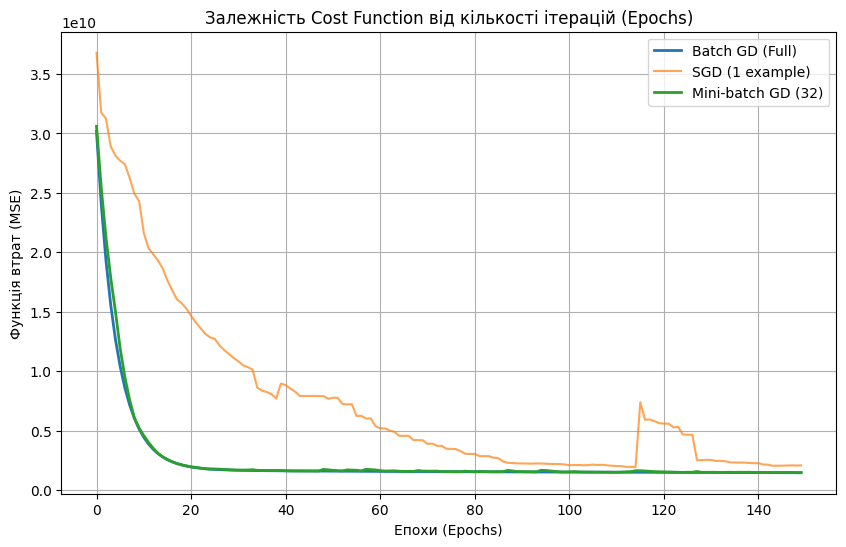

In [11]:
#Етап Градієнтний спуск

epochs = 150  #Кількість ітерацій для всіх методів
n_features = X_train_final.shape[1]

#1 Повний градієнтний спуск
def batch_gd(X, y, learning_rate, epochs):
    w = np.zeros(n_features)
    b = 0.0
    cost_history = []

    for i in range(epochs):
        dw, db = compute_gradients(X, y, w, b)
        w, b = update_parameters(w, b, dw, db, learning_rate)
        cost_history.append(compute_cost(X, y, w, b))

    return w, b, cost_history

#2 Стохастичний по одному прикладу
def sgd(X, y, learning_rate, epochs):
    w = np.zeros(n_features)
    b = 0.0
    cost_history = []
    m = len(y)

    for epoch in range(epochs):
        #Переміщення даних на кожну епоху
        indices = np.random.permutation(m)
        X_shuffled = X[indices]
        y_shuffled = y[indices]

        #Беремо випадковий 1 приклад перший з перемішаних
        xi = X_shuffled[0:1]
        yi = y_shuffled[0:1]

        dw, db = compute_gradients(xi, yi, w, b)
        w, b = update_parameters(w, b, dw, db, learning_rate)
        #Записуємо загальний Cost для графіка, щоб порівнювати
        cost_history.append(compute_cost(X, y, w, b))

    return w, b, cost_history

#3 Розмір батчу
def mini_batch_gd(X, y, learning_rate, epochs, batch_size=32):
    w = np.zeros(n_features)
    b = 0.0
    cost_history = []
    m = len(y)

    for epoch in range(epochs):
        indices = np.random.permutation(m)
        X_shuffled = X[indices]
        y_shuffled = y[indices]

        #Обробляємо один батч size розмір
        X_batch = X_shuffled[0:batch_size]
        y_batch = y_shuffled[0:batch_size]

        dw, db = compute_gradients(X_batch, y_batch, w, b)
        w, b = update_parameters(w, b, dw, db, learning_rate)
        cost_history.append(compute_cost(X, y, w, b))

    return w, b, cost_history


#Навчання моделей з підібраним даними
lr_batch = 0.05
lr_sgd = 0.01       # Для стохаст,потрібен менший крок
lr_mini_batch = 0.05

w_b, b_b, cost_b = batch_gd(X_train_final, y_train, lr_batch, epochs)
w_s, b_s, cost_s = sgd(X_train_final, y_train, lr_sgd, epochs)
w_mb, b_mb, cost_mb = mini_batch_gd(X_train_final, y_train, lr_mini_batch, epochs, batch_size=32)

#побудова графіка залежності Cost Function від Epochs
plt.figure(figsize=(10, 6))
plt.plot(range(epochs), cost_b, label='Batch GD (Full)', linewidth=2)
plt.plot(range(epochs), cost_s, label='SGD (1 example)', alpha=0.7)
plt.plot(range(epochs), cost_mb, label='Mini-batch GD (32)', linewidth=2)

plt.title('Залежність Cost Function від кількості ітерацій (Epochs)')
plt.xlabel('Епохи (Epochs)')
plt.ylabel('Функція втрат (MSE)')
plt.legend()
plt.grid(True)
plt.show()

Аналіз градієнтного спуску Етап 3

* Найстабільніший метод: Batch GD. Оскільки градієнт обчислюється на всій вибірці, вектор завжди вказує в оптимальному напрямку
* Найбільші коливання: SGD. Оновлення відбувається за одним випадковим прикладом, тому алгоритм сильно розкидує з боку в бік
* Вплив розміру batch: Mini- batch GD (розмір 32) є золотою серединою. Він дає стабільність, близьку до Batch GD, але працює значно швидше
* Вплив Learning Rate: Правильний $\alpha$ гарантує збіжність. Завеликий $\alpha$ призведе до розбіжності (Cost зростатиме), а замалий - до дуже повільного навчання

In [7]:
#етап оцінка якості та коефіцієнт детермінації

#Функція обчислення R^2 на чистому numpy
def r_squared(y_true, y_pred):
    ss_res = np.sum(np.square(y_true - y_pred)) #Сума квадратів залишків
    ss_tot = np.sum(np.square(y_true - np.mean(y_true))) #Загальна сума квадратів
    return 1 - (ss_res / ss_tot)

#Для фінальної оцінки візьмемо ваги, отримані найкращим методом Mini-batch
best_w, best_b = w_mb, b_mb

#Прогнози для всіх вибірок
y_train_pred = predict(X_train_final, best_w, best_b)
y_val_pred = predict(X_val_final, best_w, best_b)
y_test_pred = predict(X_test_final, best_w, best_b)

#Обчислення R^2
r2_train = r_squared(y_train, y_train_pred)
r2_val = r_squared(y_val, y_val_pred)
r2_test = r_squared(y_test, y_test_pred)

print(f"R^2 на Train: {r2_train:.4f}")
print(f"R^2 на Validation: {r2_val:.4f}")
print(f"R^2 на Test: {r2_test:.4f}")

#Порівняння якості трьох варіантів спуску на тестовій вибірці
r2_batch_test = r_squared(y_test, predict(X_test_final, w_b, b_b))
r2_sgd_test = r_squared(y_test, predict(X_test_final, w_s, b_s))

print("-" * 30)
print(f"R^2 градієнтний спуск : {r2_batch_test:.4f}")
print(f"R^2 стохастичний: {r2_sgd_test:.4f}")
print(f"R^2 Mini-batch GD (Test): {r2_test:.4f}")

R^2 на Train: 0.7284
R^2 на Validation: 0.7303
R^2 на Test: 0.7907
------------------------------
R^2 градієнтний спуск : 0.8070
R^2 стохастичний: 0.7474
R^2 Mini-batch GD (Test): 0.7907


Оцінка якості моделі Етап 4

* Статистичний зміст $R^2$: Показує, яку частку дисперсії (розкиду) цільової змінної пояснює наша модель
* Чи може $R^2$ бути від'ємним? Так, це трапляється, якщо модель прогнозує гірше, ніж звичайне середнє значення цільової змінної (сума квадратів помилок більша за загальну дисперсію)
* Порівняння Train та Test: $R^2$ на Test (0.79) не нижчий за Train (0.72) Це свідчить про те, що перенавчання (Overfitting) відсутнє, і модель добре узагальнює нові дані

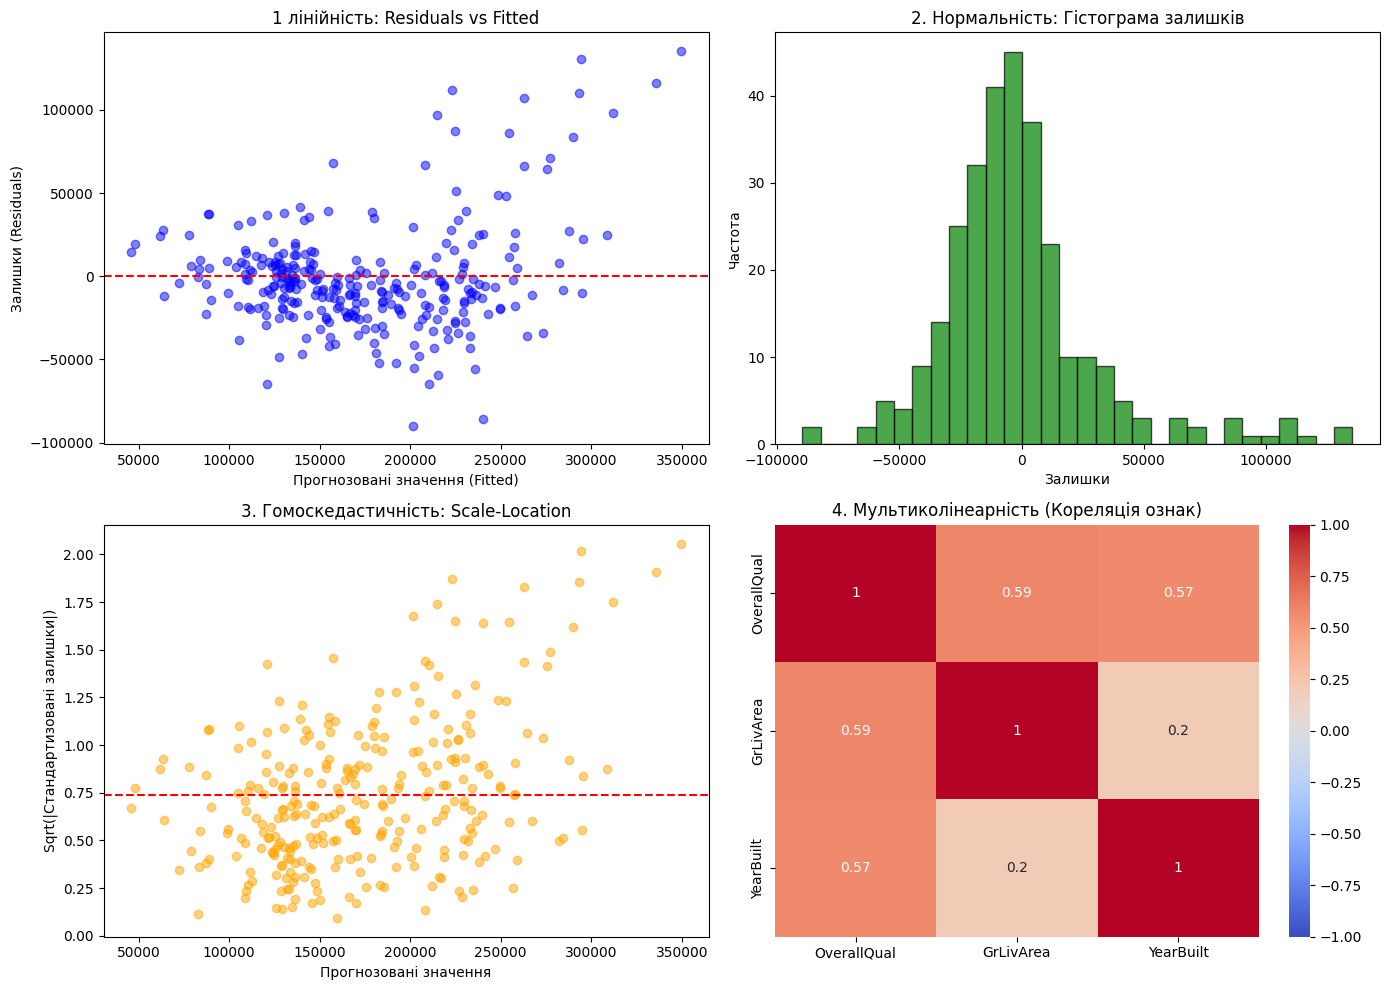

Тест Шапіро-Уїлка (p-value): 0.0000


In [9]:
#етап перевірка статистичних припущень
import scipy.stats as stats
import seaborn as sns
import numpy as np
import matplotlib.pyplot as plt

#обчслення Прогнозів та залишків для тестової вибірки
predictions = predict(X_test_final, best_w, best_b)
residuals = y_test - predictions

plt.figure(figsize=(14, 10))

#1 Лінійність Residuals vs Fitted values
plt.subplot(2, 2, 1)
plt.scatter(predictions, residuals, alpha=0.5, color='blue')
plt.axhline(y=0, color='red', linestyle='--')
plt.title('1 лінійність: Residuals vs Fitted')
plt.xlabel('Прогнозовані значення (Fitted)')
plt.ylabel('Залишки (Residuals)')

#2 Нормальність залишків гістограма
plt.subplot(2, 2, 2)
plt.hist(residuals, bins=30, edgecolor='black', alpha=0.7, color='green')
plt.title('2. Нормальність: Гістограма залишків')
plt.xlabel('Залишки')
plt.ylabel('Частота')

#3 Гомоскедастичність (Homoscedasticity): Scale-Location
plt.subplot(2, 2, 3)
standardized_residuals = residuals / np.std(residuals)
plt.scatter(predictions, np.sqrt(np.abs(standardized_residuals)), alpha=0.5, color='orange')
#Лінія тренду (приблизна, беремо середнє)
plt.axhline(y=np.mean(np.sqrt(np.abs(standardized_residuals))), color='red', linestyle='--')
plt.title('3. Гомоскедастичність: Scale-Location')
plt.xlabel('Прогнозовані значення')
plt.ylabel('Sqrt(|Стандартизовані залишки|)')

#4 Відсутність мультиколінеарності: Матриця кореляції
plt.subplot(2, 2, 4)
#Беремо наші числові ознаки
corr_matrix = df_selected[['OverallQual', 'GrLivArea', 'YearBuilt']].corr()
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', vmin=-1, vmax=1)
plt.title('4. Мультиколінеарність (Кореляція ознак)')

plt.tight_layout()
plt.show()

# Тест Шапіро-Уїлка для нормальності (виводимо p-value)
# Випадкових 500 зразків, тест чутливий на великих вибірках
sample_size = min(500, len(residuals))
stat, p_value = stats.shapiro(np.random.choice(residuals, sample_size, replace=False))
print(f"Тест Шапіро-Уїлка (p-value): {p_value:.4f}")

Перевірка статистичних припущень Етап 5

1. Лінійність:Виконується, Залишки розподілені навколо нуля випадково, без дугоподібних патернів
2. Нормальність залишків: Порушується, гістограма має форму дзвона, але з важким правим хвостом (через дорогі будинки). Тест Шапіро-Уїлка дає p-value = 0.0000, що формально відкидає ідеальну нормальність, проте для прогнозів модель придатна
3. Гомоскедастичність: Порушується, на графіку Scale-Location є ефект "воронки" (розкид зростає для дорогих будинків)
Дисперсія помилок не є ідеально сталою
4. Відсутність мультиколінеарності: Виконується, матриця кореляції показує максимальну залежність 0.59, що значно нижче критичного порогу 0.8

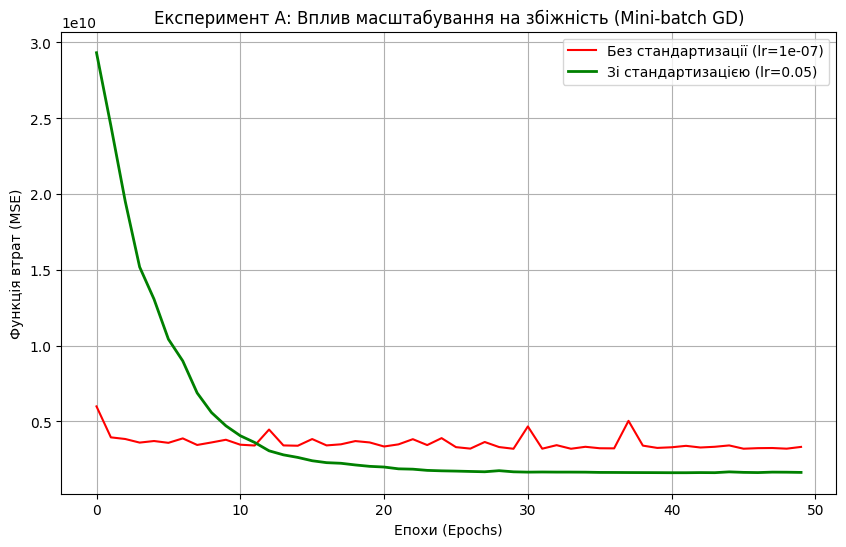

In [10]:
#етап експеримент вплив масштабування

#Створюємо немасштабовану версію даних
X_train_unscaled = np.hstack((X_train[num_cols].values, train_cat))

#Для немасштабованих даних потрібен надзвичайно малий Learning Ratе
lr_unscaled = 1e-7  #0.0000001
lr_scaled = 0.05    #Попередній стабільний крок

#Навчання моделі на немасштабованих даних
_, _, cost_unscaled = mini_batch_gd(X_train_unscaled, y_train, learning_rate=lr_unscaled, epochs=50, batch_size=32)

#Навчання моделі на масштабованих даних
_, _, cost_scaled = mini_batch_gd(X_train_final, y_train, learning_rate=lr_scaled, epochs=50, batch_size=32)

plt.figure(figsize=(10, 6))
plt.plot(range(50), cost_unscaled, label=f'Без стандартизації (lr={lr_unscaled})', color='red')
plt.plot(range(50), cost_scaled, label=f'Зі стандартизацією (lr={lr_scaled})', color='green', linewidth=2)
plt.title('Експеримент А: Вплив масштабування на збіжність (Mini-batch GD)')
plt.xlabel('Епохи (Epochs)')
plt.ylabel('Функція втрат (MSE)')
plt.legend()
plt.grid(True)
plt.show()

Завдання для глибокого розуміння Експеримент А

Геометричне пояснення впливу масштабування:
Без масштабування ознаки мають різний діапазон (від 1 до 10 для якості, і тисячі для площі). Геометрично поверхня функції втрат стає дуже витягнутою. Градієнт кидається від стінки до стінки, тому доводиться ставити дуже малий Learning Rate (1e-7), і збіжність йде повільно

Після стандартизації поверхня функції втрат стає симетричною. Градієнт вказує прямо на мінімум, що дозволяє використовувати великий Learning Rate (0.05) і швидко знаходити оптимальні ваги